# Supply-Demand Clustering — K-Means Analysis

**Dataset:** `data/clean/final_dataset_full_clean.csv`  
**Goal:** Cluster observations by the fundamental supply-demand balance to identify distinct market regimes.

Electricity prices are ultimately set by the balance between supply (how much generation is available) and demand (how much load needs to be served). When renewables are abundant relative to load, prices are low. When demand is high and generation is scarce, prices spike. This clustering checks whether those regimes are statistically separable in the data.

Features used:
- `total_load` — actual electricity consumption (MW)
- `generation_forecast` — day-ahead renewable generation forecast (MW)
- `wind_speed_10m` — upstream driver of wind generation
- `shortwave_radiation` — upstream driver of solar generation
- `price` — outcome of the supply-demand interaction (EUR/MWh)

A derived feature is also added:
- `residual_load` = `total_load` − `generation_forecast` — the portion of demand that must be met by dispatchable (non-renewable) generation. High residual load typically means high prices.

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../data/clean/final_dataset_full_clean.csv', parse_dates=['time'])
df = df.set_index('time').sort_index()

print(f'Rows: {len(df):,}  ({df.index.min().date()} — {df.index.max().date()})')
print(f'Columns: {list(df.columns)}')

Rows: 96,133  (2015-01-04 — 2025-12-31)
Columns: ['price', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'total_load', 'generation_forecast']


## 2. Derive Residual Load

`residual_load = total_load − generation_forecast`

This is one of the most important single indicators of price pressure in electricity markets. A negative residual load (generation exceeds load) can even cause negative prices.

In [2]:
df['residual_load'] = df['total_load'] - df['generation_forecast']

print('Residual load statistics (MW):')
print(df['residual_load'].describe().round(1))
print(f"\nHours with negative residual load (oversupply): {(df['residual_load'] < 0).sum():,}")

Residual load statistics (MW):
count    96133.0
mean     11058.2
std       2676.5
min      -2565.5
25%       9340.6
50%      10937.1
75%      12817.9
max      21403.9
Name: residual_load, dtype: float64

Hours with negative residual load (oversupply): 19


## 3. Select Features and Scale

In [3]:
SD_FEATURES = [
    'total_load',
    'generation_forecast',
    'residual_load',
    'wind_speed_10m',
    'shortwave_radiation',
    'price',
]

X = df[SD_FEATURES].dropna().copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Clustering matrix: {X_scaled.shape}')
print('\nFeature statistics (original scale):')
print(X.describe().round(1))

Clustering matrix: (96133, 6)

Feature statistics (original scale):
       total_load  generation_forecast  residual_load  wind_speed_10m  \
count     96133.0              96133.0        96133.0         96133.0   
mean      12171.6               1113.4        11058.2            14.2   
std        2478.7               1046.7         2676.5             6.7   
min         478.8                  0.8        -2565.5             1.8   
25%       10593.3                337.2         9340.6             9.1   
50%       11919.7                779.5        10937.1            13.0   
75%       13818.3               1575.5        12817.9            18.1   
max       21475.7               6435.0        21403.9            53.7   

       shortwave_radiation    price  
count              96133.0  96133.0  
mean                 129.2     76.7  
std                  196.0     78.9  
min                    0.0   -500.0  
25%                    0.0     34.1  
50%                    5.8     49.7  
75%     

## 4. Elbow Method — Choose k

In [ ]:
inertias = []
k_range  = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster SS)')
ax.set_title('Elbow Method — Supply-Demand Features')
plt.tight_layout()
plt.show()

## 5. Fit K-Means (k = 4)

Four clusters map to four fundamental market states:

| Regime | Residual load | Renewables | Expected price |
|--------|--------------|------------|----------------|
| Oversupply | Very low / negative | High | Low or negative |
| Balanced low demand | Low–moderate | Moderate | Below average |
| Balanced high demand | Moderate–high | Moderate | Above average |
| Scarcity | Very high | Low | High / spike |

In [4]:
K = 4
CLUSTER_COLORS = ['#2166ac', '#74add1', '#f46d43', '#a50026']
REGIME_NAMES   = ['Oversupply', 'Balanced low', 'Balanced high', 'Scarcity']

km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)

X_result = X.copy()
X_result['cluster'] = labels

# Centroids in original units
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=SD_FEATURES,
).round(1)
centroids.index.name = 'Cluster'
print('Cluster centroids (original scale):')
print(centroids)

Cluster centroids (original scale):
         total_load  generation_forecast  residual_load  wind_speed_10m  \
Cluster                                                                   
0           11312.2                690.1        10622.1            10.6   
1           12007.0               2764.9         9242.1            23.6   
2            9357.0                745.8         8611.2            14.1   
3           15126.3                752.3        14373.9            13.3   

         shortwave_radiation  price  
Cluster                              
0                       37.0   97.2  
1                       63.0   63.9  
2                      495.8   62.4  
3                      139.7   60.4  


## 6. Residual Load vs Price

This is the core supply-demand relationship: as residual load rises (less renewable surplus to cover demand), prices should increase. The clusters should separate along this axis.

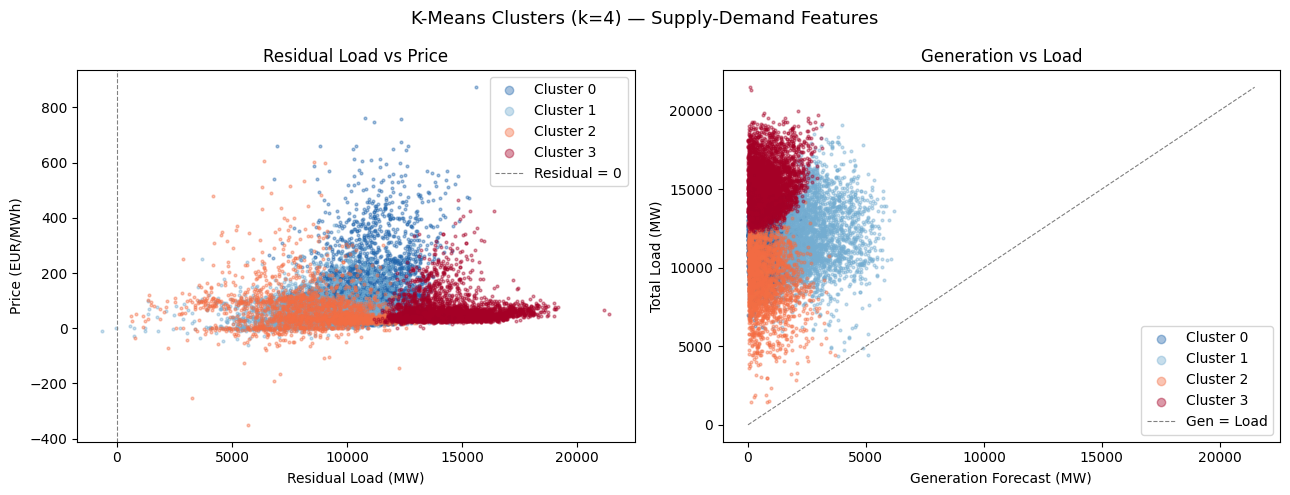

In [5]:
sample = X_result.iloc[::6]  # every 6th hour for readability

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: Residual load vs Price ---
for c in range(K):
    mask = sample['cluster'] == c
    axes[0].scatter(sample.loc[mask, 'residual_load'], sample.loc[mask, 'price'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')
axes[0].axvline(0, linestyle='--', color='grey', linewidth=0.8, label='Residual = 0')
axes[0].set_xlabel('Residual Load (MW)')
axes[0].set_ylabel('Price (EUR/MWh)')
axes[0].set_title('Residual Load vs Price')
axes[0].legend(markerscale=3)

# --- Right: Generation forecast vs Total load ---
for c in range(K):
    mask = sample['cluster'] == c
    axes[1].scatter(sample.loc[mask, 'generation_forecast'], sample.loc[mask, 'total_load'],
                    s=4, alpha=0.4, color=CLUSTER_COLORS[c], label=f'Cluster {c}')
# Diagonal: generation = load (zero residual)
lims = [min(sample['generation_forecast'].min(), sample['total_load'].min()),
        max(sample['generation_forecast'].max(), sample['total_load'].max())]
axes[1].plot(lims, lims, '--', color='grey', linewidth=0.8, label='Gen = Load')
axes[1].set_xlabel('Generation Forecast (MW)')
axes[1].set_ylabel('Total Load (MW)')
axes[1].set_title('Generation vs Load')
axes[1].legend(markerscale=3)

fig.suptitle('K-Means Clusters (k=4) — Supply-Demand Features', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Price Distribution per Cluster

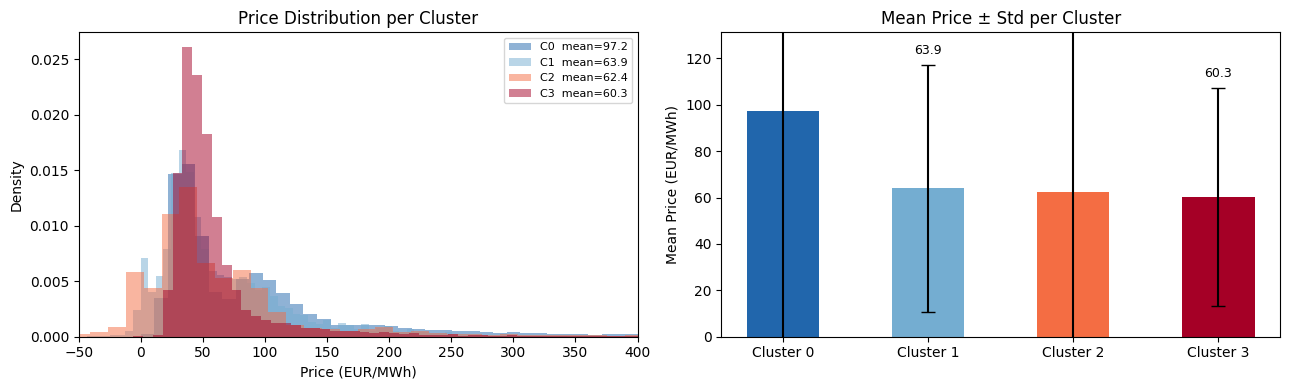

In [6]:
price_stats = X_result.groupby('cluster')['price'].agg(['mean', 'std', 'median'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overlapping histograms
for c in range(K):
    prices = X_result.loc[X_result['cluster'] == c, 'price']
    axes[0].hist(prices, bins=80, alpha=0.5, color=CLUSTER_COLORS[c],
                 label=f'C{c}  mean={prices.mean():.1f}', density=True)
axes[0].set_xlabel('Price (EUR/MWh)')
axes[0].set_ylabel('Density')
axes[0].set_title('Price Distribution per Cluster')
axes[0].legend(fontsize=8)
axes[0].set_xlim(-50, 400)

# Mean ± std bar chart
bars = axes[1].bar(
    [f'Cluster {c}' for c in price_stats.index],
    price_stats['mean'],
    yerr=price_stats['std'],
    color=CLUSTER_COLORS,
    width=0.5,
    capsize=5,
)
axes[1].bar_label(bars, fmt='%.1f', padding=6, fontsize=9)
axes[1].set_ylabel('Mean Price (EUR/MWh)')
axes[1].set_title('Mean Price ± Std per Cluster')
axes[1].set_ylim(0, price_stats['mean'].max() * 1.35)

plt.tight_layout()
plt.show()

## 8. Residual Load Distribution per Cluster

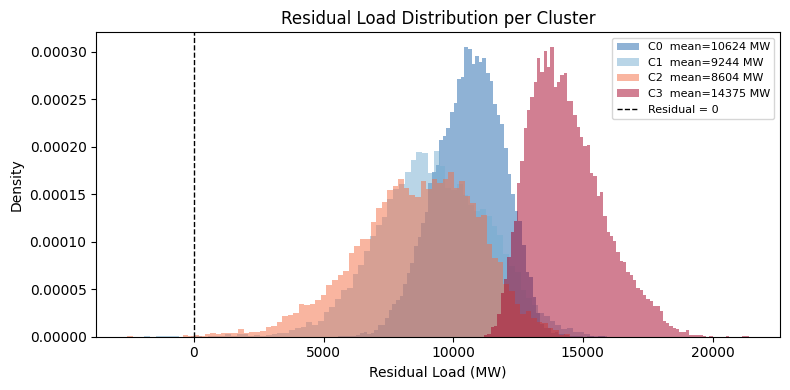

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

for c in range(K):
    rl = X_result.loc[X_result['cluster'] == c, 'residual_load']
    ax.hist(rl, bins=80, alpha=0.5, color=CLUSTER_COLORS[c],
            label=f'C{c}  mean={rl.mean():.0f} MW', density=True)

ax.axvline(0, linestyle='--', color='black', linewidth=1, label='Residual = 0')
ax.set_xlabel('Residual Load (MW)')
ax.set_ylabel('Density')
ax.set_title('Residual Load Distribution per Cluster')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Cluster Share over Time

Plotting monthly cluster proportions shows how market regimes shift across years — including the 2022 energy crisis period.

In [ ]:
X_result['year_month'] = df.loc[X.index, 'month'].values  # placeholder: use full datetime
X_result.index = df.loc[X.index].index  # restore datetime index

monthly = X_result.resample('ME')['cluster'].value_counts(normalize=True).unstack(fill_value=0) * 100

fig, ax = plt.subplots(figsize=(14, 4))
bottom = np.zeros(len(monthly))
for c in range(K):
    if c in monthly.columns:
        ax.bar(monthly.index, monthly[c], bottom=bottom,
               color=CLUSTER_COLORS[c], label=f'Cluster {c}', width=25)
        bottom += monthly[c].values

ax.set_xlabel('Date')
ax.set_ylabel('% of hours in month')
ax.set_title('Monthly Supply-Demand Regime Distribution')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 10. Interpretation

- **Residual load drives price**: Clusters with high residual load (high demand, low renewables) should consistently show higher mean prices, confirming the merit-order effect.
- **Oversupply cluster**: Hours where `generation_forecast > total_load` form a distinct low/negative-price cluster. This regime has become more common as renewable capacity has grown across the decade.
- **Scarcity cluster**: A small, high-price cluster corresponding to cold winter evenings with low wind and solar. These observations dominate the price variance and represent the tail-risk that forecasting models must capture.
- **2022 crisis visibility**: The monthly cluster share plot should show a sharp increase in the scarcity cluster during late 2021–2022, reflecting the gas price shock that raised the cost of dispatchable generation.
- **Implication for forecasting**: `residual_load` is a strong single predictor. Including both `total_load` and `generation_forecast` (rather than just their difference) lets the model learn non-linear interactions — e.g., high load *and* high wind is very different from high load *and* low wind.